# Compare models


## Load results from models
Format : liste [num de frame, x_centroïde, y_centroïde, confiance]

### YOLO

In [6]:
import cv2
from ultralytics import YOLO

def extraire_centroid_balle_bbox(model_path, target_class, video_path, frame_step=1):
    # 1. Chargement du modèle
    model = YOLO(model_path)
    
    # Identification de l'ID de la classe
    class_ids = {v: k for k, v in model.names.items()}
    if target_class not in class_ids:
        print(f"Classe '{target_class}' introuvable.")
        return []
    target_id = class_ids[target_class]

    cap = cv2.VideoCapture(video_path)
    resultats_centroids = []
    frame_idx = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % frame_step == 0:
            # Inférence
            results = model(frame, verbose=False)[0]
            
            # On parcourt les boîtes détectées
            for box in results.boxes:
                cls_id = int(box.cls[0])
                if cls_id == target_id:
                    # On peut utiliser .xywh qui donne directement le centre (x, y)
                    # format : [x_centre, y_centre, largeur, hauteur]
                    x_c, y_c, w, h = box.xywh[0].tolist()
                    
                    conf = float(box.conf[0])
                    
                    # On stocke : [Frame, Centroïde_X, Centroïde_Y, Confiance]
                    resultats_centroids.append([frame_idx, int(x_c), int(y_c), conf])

        frame_idx += 1

    cap.release()
    return resultats_centroids



In [ ]:
yolo_immobile = extraire_centroid_balle_bbox("roboflow/models/best-2.pt", "ball", "roboflow/dataset_labelise/video_immobile/video_immobile.mp4", frame_step=10)
for res in yolo_immobile[:10]:
    print(f"Frame {res[0]} : X={res[1]}, Y={res[2]}, Conf={res[3]}")

Frame 0 : X=341, Y=361, Conf=0.9754864573478699
Frame 15 : X=341, Y=361, Conf=0.970394492149353
Frame 30 : X=341, Y=361, Conf=0.9737160801887512
Frame 45 : X=341, Y=361, Conf=0.9726187586784363
Frame 60 : X=341, Y=361, Conf=0.9750104546546936
Frame 75 : X=341, Y=361, Conf=0.974850058555603
Frame 90 : X=341, Y=361, Conf=0.975992739200592
Frame 105 : X=341, Y=361, Conf=0.9746991395950317
Frame 120 : X=341, Y=361, Conf=0.9720868468284607
Frame 135 : X=341, Y=361, Conf=0.9717828035354614


In [32]:
yolo_lent = extraire_centroid_balle_bbox("roboflow/models/best-2.pt", "ball", "roboflow/dataset_labelise/video_lente/video_lente.mp4", frame_step=5)

In [7]:
yolo_simple = extraire_centroid_balle_bbox("roboflow/models/best-2.pt", "ball", "roboflow/dataset_labelise/video_simple/video_simple.mp4", frame_step=5)

### CV2

In [1]:
import cv2
import numpy as np
from utils.tracking_utils_2D import BallTracker, PlayerDetector, TablePnPEstimator, PingPongUmpire, CourtVisualizer

clicked_points = []

def mouse_callback(event, x, y, flags, param):
    global clicked_points
    if event == cv2.EVENT_LBUTTONDOWN and len(clicked_points) < 4:
        clicked_points.append((x, y))

def main(video_path):
    global clicked_points
    # --- 1. INITIALISATION DE LA LISTE ---
    ball_positions = [] 
    
    VIDEO_PATH = video_path
    WINDOW_MAIN = "Smart Tracker (Video)"
    WINDOW_3D = "3D Court Radar"
    TARGET_WIDTH = 800
    LOOP_VIDEO = False # Mis à False pour que la fonction se termine et renvoie la liste

    cv2.namedWindow(WINDOW_MAIN, cv2.WINDOW_NORMAL)
    cv2.namedWindow(WINDOW_3D, cv2.WINDOW_NORMAL)
    cv2.setMouseCallback(WINDOW_MAIN, mouse_callback)

    ball_tracker = BallTracker(buffer_size=32, max_jump_dist=400, window_name=WINDOW_MAIN)
    ball_tracker.setup_trackbars()
    player_detector = PlayerDetector()
    umpire = PingPongUmpire()
    visualizer = CourtVisualizer(scale=0.15)

    stream = cv2.VideoCapture(VIDEO_PATH)
    if not stream.isOpened(): return []

    ret, initial_frame = stream.read()
    if not ret: return []
    
    height, width = initial_frame.shape[:2]

    pnp_estimator = TablePnPEstimator(frame_width=width, frame_height=height)
    
    while len(clicked_points) < 4:
        temp_frame = initial_frame.copy()
        for pt in clicked_points:
            cv2.circle(temp_frame, pt, 5, (0, 255, 255), -1)
        
        instruction = f"Click 4 corners: Net L, Near L, Near R, Net R ({len(clicked_points)}/4)"
        cv2.putText(temp_frame, instruction, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)
        cv2.imshow(WINDOW_MAIN, temp_frame)
        if cv2.waitKey(1) == ord('q'): return []

    pnp_estimator.update_camera_pose(clicked_points)
    stream.set(cv2.CAP_PROP_POS_FRAMES, 0)

    display_text = ""
    display_timer = 0

    print("Analyse lancée... Appuyez sur 'q' pour arrêter et récupérer les données.")

    while True:
        # --- 2. RÉCUPÉRER L'INDEX DE LA FRAME ---
        current_frame_idx = int(stream.get(cv2.CAP_PROP_POS_FRAMES))
        
        ret, frame = stream.read()
        if not ret:
            break # Fin de la vidéo, on sort de la boucle pour renvoyer la liste

        
        cv2.polylines(frame, [np.int32(clicked_points)], True, (0, 255, 0), 2)
        for pt in clicked_points:
            cv2.circle(frame, pt, 5, (0, 255, 255), -1)

        frame = player_detector.process(frame)
        frame, ball_center, ball_w = ball_tracker.process(frame)
        
        # --- 3. STOCKAGE DES COORDONNÉES ---
        # On enregistre même si ball_center est None (pour garder la synchro frame par frame)
        # ou seulement si détecté, selon ton besoin. Ici, on enregistre les détections :
        if ball_center is not None:
            conf = getattr(ball_tracker, 'last_confidence', 1.0)
            ball_positions.append([
                current_frame_idx, 
                round(ball_center[0], 2), 
                round(ball_center[1], 2), 
                round(conf, 2)
            ])
        
        current_table_coords = None
        if ball_center is not None and pnp_estimator.rvec is not None:
            bx, by = ball_center
            table_coords = pnp_estimator.project_ball_to_table_plane(bx, by)
            if table_coords:
                current_table_coords = table_coords
                wx, wy = table_coords
                bounce_result = umpire.update(by, wx, wy)
                if bounce_result:
                    display_text = bounce_result
                    display_timer = 45 

        minimap = visualizer.draw(table_coords=current_table_coords, text=display_text if display_timer > 0 else "")

        if display_timer > 0:
            color = (0, 255, 0) if "IN" in display_text else (0, 0, 255)
            cv2.putText(frame, display_text, (50, 100), cv2.FONT_HERSHEY_SIMPLEX, 1.5, color, 4, cv2.LINE_AA)
            display_timer -= 1

        cv2.imshow(WINDOW_MAIN, frame)
        cv2.imshow(WINDOW_3D, minimap)

        if cv2.waitKey(1) == ord('q'): break

    stream.release()
    cv2.destroyAllWindows()
    
    return ball_positions


In [2]:
CV2_ball_immobile = main("roboflow/dataset_labelise/video_immobile/video_immobile.mp4")
for res in CV2_ball_immobile[:10]:
    print(f"Frame {res[0]} : X={res[1]}, Y={res[2]}, Conf={res[3]}")

I0000 00:00:1773158442.358107  165961 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1773158442.457817  166201 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773158442.475027  166201 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Analyse lancée... Appuyez sur 'q' pour arrêter et récupérer les données.
Frame 0 : X=341, Y=364, Conf=1.0
Frame 1 : X=341, Y=364, Conf=1.0
Frame 2 : X=341, Y=364, Conf=1.0
Frame 3 : X=341, Y=364, Conf=1.0
Frame 4 : X=341, Y=364, Conf=1.0
Frame 5 : X=341, Y=364, Conf=1.0
Frame 6 : X=341, Y=364, Conf=1.0
Frame 7 : X=341, Y=364, Conf=1.0
Frame 8 : X=341, Y=364, Conf=1.0
Frame 9 : X=341, Y=364, Conf=1.0


In [3]:
CV2_ball_lente = main("roboflow/dataset_labelise/video_lente/video_lente.mp4")
for res in CV2_ball_lente[:10]:
    print(f"Frame {res[0]} : X={res[1]}, Y={res[2]}, Conf={res[3]}")

I0000 00:00:1773161036.265332  208756 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1773161036.376391  209022 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773161036.393926  209022 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Analyse lancée... Appuyez sur 'q' pour arrêter et récupérer les données.


W0000 00:00:1773161044.867667  209018 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


Frame 2 : X=417, Y=397, Conf=1.0
Frame 3 : X=417, Y=397, Conf=1.0
Frame 4 : X=417, Y=397, Conf=1.0
Frame 5 : X=417, Y=397, Conf=1.0
Frame 6 : X=417, Y=397, Conf=1.0
Frame 7 : X=417, Y=397, Conf=1.0
Frame 8 : X=633, Y=244, Conf=1.0
Frame 9 : X=631, Y=240, Conf=1.0
Frame 10 : X=629, Y=235, Conf=1.0
Frame 11 : X=626, Y=231, Conf=1.0


In [2]:
CV2_ball_simple = main("roboflow/dataset_labelise/video_simple/video_simple.mp4")
#for res in CV2_ball_lente[:10]:
   #print(f"Frame {res[0]} : X={res[1]}, Y={res[2]}, Conf={res[3]}")

I0000 00:00:1773161079.315701  209447 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1773161079.421865  209626 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773161079.438937  209624 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Analyse lancée... Appuyez sur 'q' pour arrêter et récupérer les données.


W0000 00:00:1773161086.370942  209622 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


## Comparaison avec le fichier labellisé

In [4]:
import pandas as pd
import numpy as np

def calculer_distances_eucl(video_nom_cible, results, csv_path):
    
    # 1. Chargement du CSV avec gestion du header
    df_gt = pd.read_csv(csv_path)
    
    # On récupère le nom des colonnes pour être flexible
    # Supposons : col 0 = video, col 1 = frame, col 2-5 = x1, y1, x2, y2
    cols = df_gt.columns
    col_video = cols[0]
    col_frame = cols[1]
    
    # 2. Filtrage strict sur le nom de la vidéo
    df_video = df_gt[df_gt[col_video] == video_nom_cible].copy()
    
    if df_video.empty:
        print(f"Attention : Aucune donnée trouvée pour la vidéo '{video_nom_cible}'")
        return []

    # 3. Calcul des centroïdes Ground Truth (GT)
    # Formule : (x1 + x2) / 2
    df_video['cx_gt'] = (df_video[cols[2]] + df_video[cols[4]]) / 2
    df_video['cy_gt'] = (df_video[cols[3]] + df_video[cols[5]]) / 2
    
    # Création d'un dictionnaire pour mapper {frame_id: (cx, cy)}
    gt_map = df_video.set_index(col_frame)[['cx_gt', 'cy_gt']].to_dict('index')
    print(gt_map)  # Affiche les premiers frame_id pour vérification
    distances_finales = []

    # 4. Comparaison avec les résultats 
    for res in results:
        f_idx, cx, cy, _ = res
        
        # On vérifie si le numéro de frame existe dans le CSV filtré
        if f_idx in gt_map:
            gt_cx = gt_map[f_idx]['cx_gt']
            gt_cy = gt_map[f_idx]['cy_gt']
            
            # Calcul de la distance euclidienne
            dist = np.sqrt((cx - gt_cx)**2 + (cy - gt_cy)**2)
            distances_finales.append(dist)
        else:
            # Optionnel : log si une frame analysée n'est pas labellisée
            pass

    return distances_finales

In [23]:
error_yolo_immobile = calculer_distances_eucl("video_immobile", yolo_immobile, "roboflow/dataset_labelise/annotations.csv")

{0: {'cx_gt': 341.405, 'cy_gt': 361.21000000000004}, 15: {'cx_gt': 341.405, 'cy_gt': 361.605}, 30: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 45: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 60: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 75: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 90: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 105: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 120: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 135: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 150: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 165: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 180: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 195: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 210: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 225: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 240: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}}


In [33]:
error_yolo_lente = calculer_distances_eucl("video_lente", yolo_lent, "roboflow/dataset_labelise/annotations.csv")

{0: {'cx_gt': nan, 'cy_gt': nan}, 15: {'cx_gt': 603.975, 'cy_gt': 234.42000000000002}, 30: {'cx_gt': 546.77, 'cy_gt': 322.46000000000004}, 45: {'cx_gt': 557.4300000000001, 'cy_gt': 409.38}, 60: {'cx_gt': 557.4300000000001, 'cy_gt': 428.45}, 75: {'cx_gt': 557.4300000000001, 'cy_gt': 424.525}, 90: {'cx_gt': 477.24, 'cy_gt': 193.48000000000002}, 105: {'cx_gt': 441.35, 'cy_gt': 295.53999999999996}, 120: {'cx_gt': 457.04999999999995, 'cy_gt': 421.15999999999997}, 135: {'cx_gt': 460.40999999999997, 'cy_gt': 427.89}, 150: {'cx_gt': 462.1, 'cy_gt': 427.89}, 165: {'cx_gt': 459.85, 'cy_gt': 420.03999999999996}, 180: {'cx_gt': 268.065, 'cy_gt': 196.845}, 195: {'cx_gt': 199.085, 'cy_gt': 215.355}, 210: {'cx_gt': 171.61, 'cy_gt': 349.935}, 225: {'cx_gt': 181.135, 'cy_gt': 412.75}, 240: {'cx_gt': 183.89499999999998, 'cy_gt': 410.97}, 255: {'cx_gt': 185.82999999999998, 'cy_gt': 345.395}, 270: {'cx_gt': 243.235, 'cy_gt': 204.57999999999998}, 285: {'cx_gt': 443.82, 'cy_gt': 100.305}, 300: {'cx_gt': nan

In [8]:
error_yolo_simple = calculer_distances_eucl("video_simple", yolo_simple, "roboflow/dataset_labelise/annotations.csv")

{0: {'cx_gt': nan, 'cy_gt': nan}, 5: {'cx_gt': 219.1, 'cy_gt': 238.965}, 10: {'cx_gt': 201.055, 'cy_gt': 364.005}, 15: {'cx_gt': nan, 'cy_gt': nan}, 20: {'cx_gt': nan, 'cy_gt': nan}, 25: {'cx_gt': nan, 'cy_gt': nan}, 30: {'cx_gt': nan, 'cy_gt': nan}, 35: {'cx_gt': nan, 'cy_gt': nan}, 40: {'cx_gt': nan, 'cy_gt': nan}, 45: {'cx_gt': nan, 'cy_gt': nan}, 50: {'cx_gt': nan, 'cy_gt': nan}, 55: {'cx_gt': 352.06, 'cy_gt': 204.26999999999998}, 60: {'cx_gt': 327.405, 'cy_gt': 296.865}, 65: {'cx_gt': 325.0, 'cy_gt': 232.53}, 70: {'cx_gt': 347.85, 'cy_gt': 167.89499999999998}, 75: {'cx_gt': 467.885, 'cy_gt': 11.085}, 80: {'cx_gt': nan, 'cy_gt': nan}, 85: {'cx_gt': nan, 'cy_gt': nan}, 90: {'cx_gt': nan, 'cy_gt': nan}, 95: {'cx_gt': nan, 'cy_gt': nan}, 100: {'cx_gt': nan, 'cy_gt': nan}, 105: {'cx_gt': 75.765, 'cy_gt': 16.755000000000003}, 110: {'cx_gt': 76.095, 'cy_gt': 308.66}, 115: {'cx_gt': 94.72, 'cy_gt': 301.125}, 120: {'cx_gt': 67.015, 'cy_gt': 214.98000000000002}, 125: {'cx_gt': nan, 'cy_gt':

In [25]:
error_CV2_immobile = calculer_distances_eucl("video_immobile", CV2_ball_immobile, "roboflow/dataset_labelise/annotations.csv")

{0: {'cx_gt': 341.405, 'cy_gt': 361.21000000000004}, 15: {'cx_gt': 341.405, 'cy_gt': 361.605}, 30: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 45: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 60: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 75: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 90: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 105: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 120: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 135: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 150: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 165: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 180: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 195: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 210: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 225: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}, 240: {'cx_gt': 342.595, 'cy_gt': 361.21000000000004}}


In [34]:
error_CV2_lente=calculer_distances_eucl("video_lente", CV2_ball_lente, "roboflow/dataset_labelise/annotations.csv")
print(len(error_CV2_lente), len(error_yolo_lente))

{0: {'cx_gt': nan, 'cy_gt': nan}, 15: {'cx_gt': 603.975, 'cy_gt': 234.42000000000002}, 30: {'cx_gt': 546.77, 'cy_gt': 322.46000000000004}, 45: {'cx_gt': 557.4300000000001, 'cy_gt': 409.38}, 60: {'cx_gt': 557.4300000000001, 'cy_gt': 428.45}, 75: {'cx_gt': 557.4300000000001, 'cy_gt': 424.525}, 90: {'cx_gt': 477.24, 'cy_gt': 193.48000000000002}, 105: {'cx_gt': 441.35, 'cy_gt': 295.53999999999996}, 120: {'cx_gt': 457.04999999999995, 'cy_gt': 421.15999999999997}, 135: {'cx_gt': 460.40999999999997, 'cy_gt': 427.89}, 150: {'cx_gt': 462.1, 'cy_gt': 427.89}, 165: {'cx_gt': 459.85, 'cy_gt': 420.03999999999996}, 180: {'cx_gt': 268.065, 'cy_gt': 196.845}, 195: {'cx_gt': 199.085, 'cy_gt': 215.355}, 210: {'cx_gt': 171.61, 'cy_gt': 349.935}, 225: {'cx_gt': 181.135, 'cy_gt': 412.75}, 240: {'cx_gt': 183.89499999999998, 'cy_gt': 410.97}, 255: {'cx_gt': 185.82999999999998, 'cy_gt': 345.395}, 270: {'cx_gt': 243.235, 'cy_gt': 204.57999999999998}, 285: {'cx_gt': 443.82, 'cy_gt': 100.305}, 300: {'cx_gt': nan

In [5]:
error_CV2_simple=calculer_distances_eucl("video_simple", CV2_ball_simple, "roboflow/dataset_labelise/annotations.csv")

{0: {'cx_gt': nan, 'cy_gt': nan}, 5: {'cx_gt': 219.1, 'cy_gt': 238.965}, 10: {'cx_gt': 201.055, 'cy_gt': 364.005}, 15: {'cx_gt': nan, 'cy_gt': nan}, 20: {'cx_gt': nan, 'cy_gt': nan}, 25: {'cx_gt': nan, 'cy_gt': nan}, 30: {'cx_gt': nan, 'cy_gt': nan}, 35: {'cx_gt': nan, 'cy_gt': nan}, 40: {'cx_gt': nan, 'cy_gt': nan}, 45: {'cx_gt': nan, 'cy_gt': nan}, 50: {'cx_gt': nan, 'cy_gt': nan}, 55: {'cx_gt': 352.06, 'cy_gt': 204.26999999999998}, 60: {'cx_gt': 327.405, 'cy_gt': 296.865}, 65: {'cx_gt': 325.0, 'cy_gt': 232.53}, 70: {'cx_gt': 347.85, 'cy_gt': 167.89499999999998}, 75: {'cx_gt': 467.885, 'cy_gt': 11.085}, 80: {'cx_gt': nan, 'cy_gt': nan}, 85: {'cx_gt': nan, 'cy_gt': nan}, 90: {'cx_gt': nan, 'cy_gt': nan}, 95: {'cx_gt': nan, 'cy_gt': nan}, 100: {'cx_gt': nan, 'cy_gt': nan}, 105: {'cx_gt': 75.765, 'cy_gt': 16.755000000000003}, 110: {'cx_gt': 76.095, 'cy_gt': 308.66}, 115: {'cx_gt': 94.72, 'cy_gt': 301.125}, 120: {'cx_gt': 67.015, 'cy_gt': 214.98000000000002}, 125: {'cx_gt': nan, 'cy_gt':

In [10]:
import matplotlib.pyplot as plt

def plot_error_comparison(frames, errors_yolo, errors_manual):
    plt.figure(figsize=(12, 6))
    
    plt.plot(frames, errors_yolo, label='Erreur YOLO', color='blue', alpha=0.7)
    plt.plot(frames, errors_manual, label='Erreur BallTracker', color='red', alpha=0.7)
    
    plt.title("Comparaison de la précision des Trackers (Distance Euclidienne)")
    plt.xlabel("Numéro de la Frame")
    plt.ylabel("Erreur L2")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.show()

# Calcul de l'erreur moyenne (MAE) pour ton rapport
# $MAE = \frac{1}{n} \sum_{i=1}^{n} \sqrt{(x_i - \hat{x}_i)^2 + (y_i - \hat{y}_i)^2}$

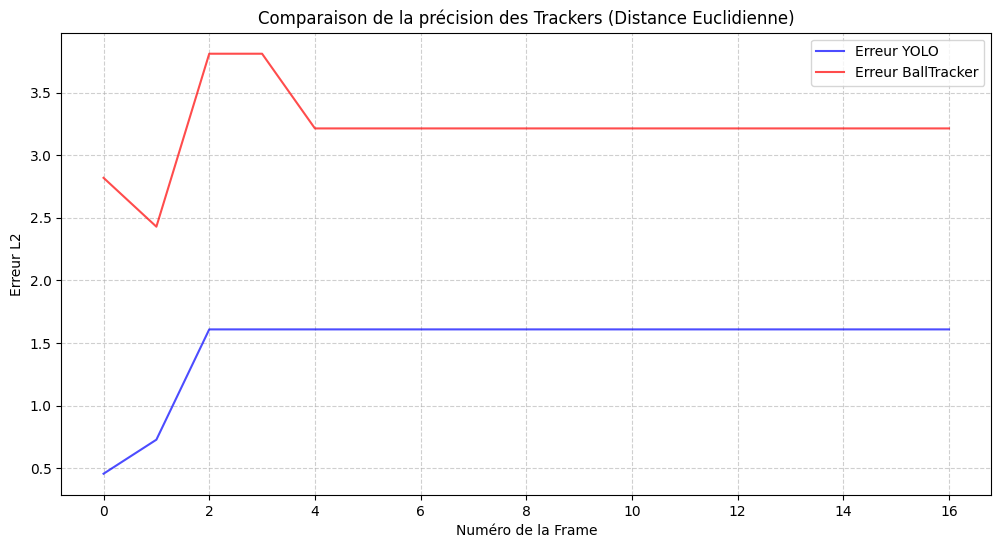

In [43]:
plot_error_comparison(list(range(len(error_CV2_immobile))), error_yolo_immobile, error_CV2_immobile)

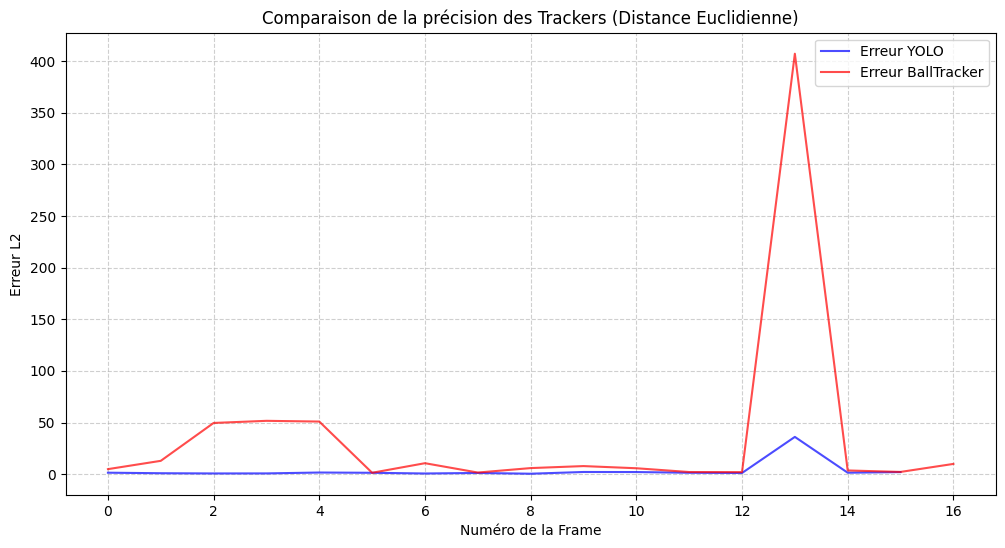

In [44]:
plot_error_comparison(list(range(len(error_yolo_lente))), error_yolo_lente, error_CV2_lente[:len(error_yolo_lente)])

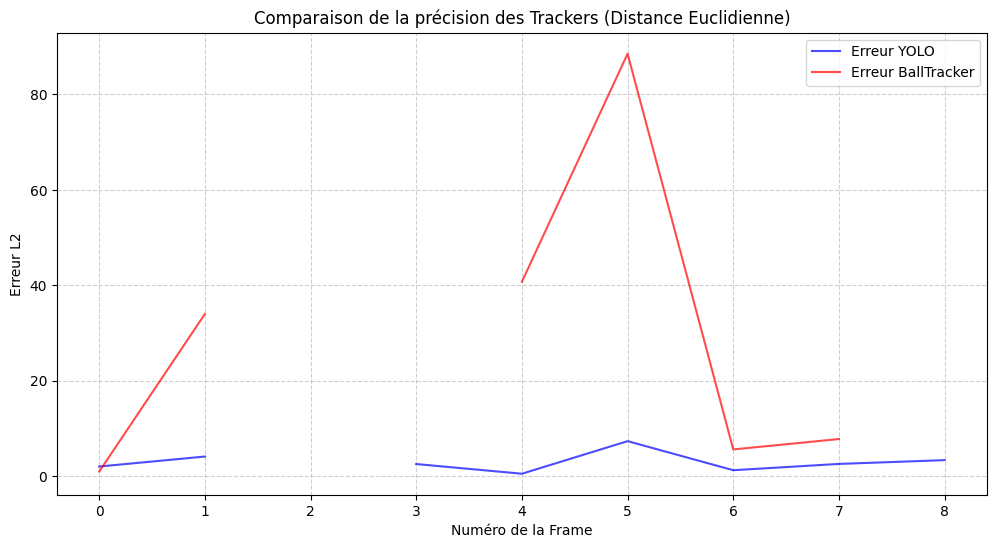

In [11]:
plot_error_comparison(list(range(len(error_yolo_simple))), error_yolo_simple, error_CV2_simple[:len(error_yolo_simple)])